In [38]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType , HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator
import operator
from math import prod
from itertools import product

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
nside = 4
npixel = 12 * nside**2
stokes_type: ValidStokesType = 'IQU'
frequency_count = 10

In [40]:
comp_keys = jax.random.split(jax.random.PRNGKey(0), 3)
stokes_cls = StokesPyTree.class_for(stokes_type)
frequencies = jnp.logspace(10, 12, num=frequency_count)

sky = {
    'cmb': stokes_cls.normal(comp_keys[0], (npixel, )),
    'dust': stokes_cls.normal(comp_keys[1], (npixel, )),
    'synchrotron': stokes_cls.normal(comp_keys[2], (npixel, )),
}

In [56]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

def cluster_map(nside, patches_per_row):
    npixel = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npixel), nest=False)
    
    # Initialize patch map
    patch_map = np.full(npixel, -1, dtype=int)
    patch_id = 0

    # Calculate row boundaries based on theta
    row_boundaries = np.linspace(0, np.pi, len(patches_per_row) + 1)

    for i, patches in enumerate(patches_per_row):
        # Pixels in the current row
        in_row = (theta >= row_boundaries[i]) & (theta < row_boundaries[i + 1])

        # Divide this row into patches based on phi
        phi_bins = np.linspace(0, 2 * np.pi, patches + 1)
        
        for j in range(patches):
            # Select pixels in the current patch
            in_patch = in_row & (phi >= phi_bins[j]) & (phi < phi_bins[j + 1])
            patch_map[in_patch] = patch_id
            patch_id += 1

    return patch_map


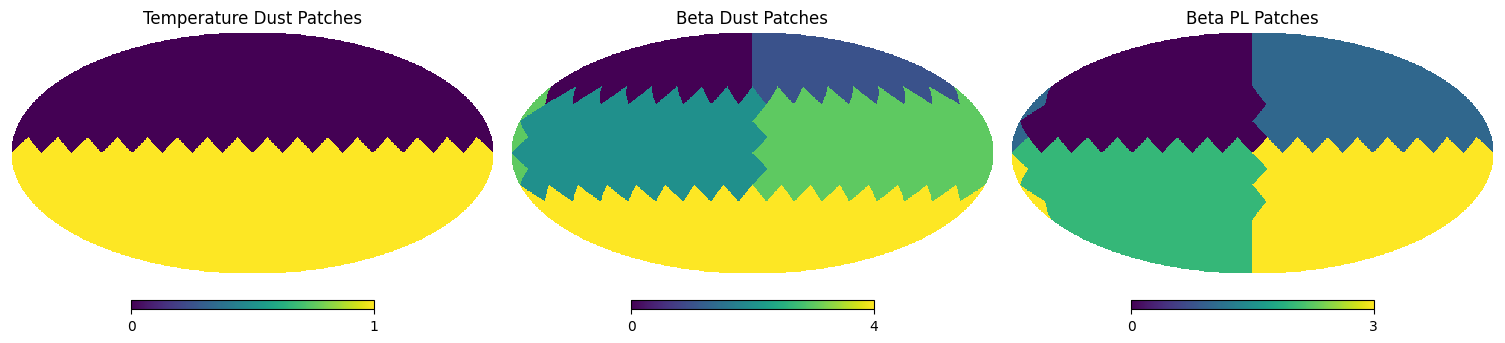

In [57]:
temp_dust_patches = [1 , 1]
beta_dust_patches = [2, 2, 1]
beta_pl_patches = [2, 2]

temp_dust_patch_indices = cluster_map(nside, temp_dust_patches)
beta_dust_patch_indices = cluster_map(nside, beta_dust_patches)
beta_pl_patch_indices = cluster_map(nside, beta_pl_patches)

temp_dust_patch_count = sum(temp_dust_patches)
beta_dust_patch_count = sum(beta_dust_patches)
beta_pl_patch_count = sum(beta_pl_patches)


# Set up subplots
fig= plt.figure(figsize=(15, 5))
# Plot each map
hp.mollview(temp_dust_patch_indices,title='Temperature Dust Patches', sub=(1, 3, 1))
hp.mollview(beta_dust_patch_indices, title='Beta Dust Patches', sub=(1, 3, 2))
hp.mollview(beta_pl_patch_indices, title='Beta PL Patches', sub=(1, 3, 3))

# Display the plot
plt.show()

In [58]:
def make_mixing_matrix_operator(params,patch_indices, in_structure):
    cmb = CMBOperator(frequencies, in_structure=in_structure)
    dust = DustOperator(
        frequencies,
        temperature=params['temp_dust'],
        temperature_patch_indices=patch_indices['temp_dust_patches'],
        beta=params['beta_dust'],
        beta_patch_indices=patch_indices['beta_dust_patches'],
        in_structure=in_structure,
    )
    synchrotron = SynchrotronOperator(frequencies,
                                      beta_pl=params['beta_pl'],
                                     beta_pl_patch_indices=patch_indices['beta_pl_patches'],
                                      in_structure=in_structure)
    sed = BlockDiagonalOperator({
        'cmb': cmb,
        'dust': dust,
        'synchrotron': synchrotron
    })
    integ = BlockRowOperator({
        component:
        IdentityOperator(sed.blocks[component].out_structure())
        for component in sed.blocks
    })
    return (integ @ sed).reduce()

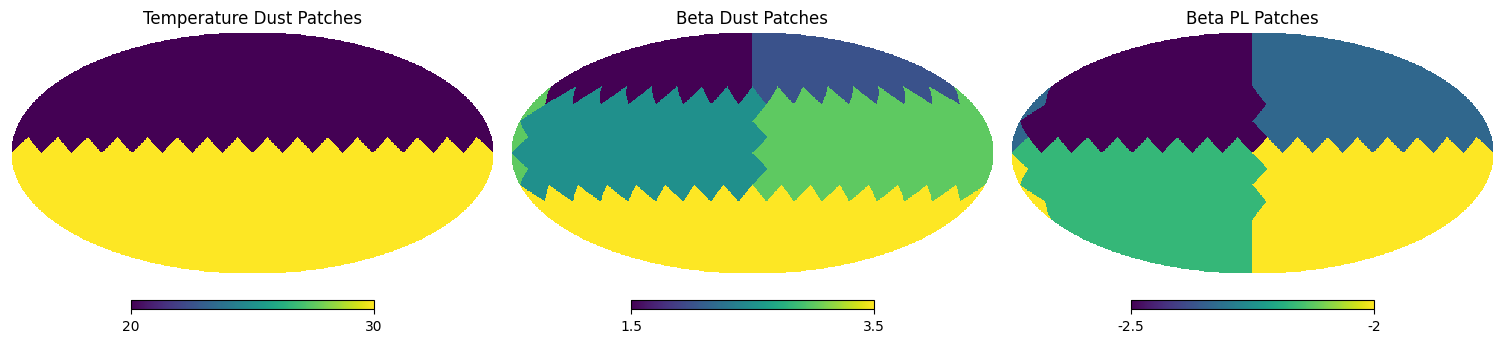

In [75]:

temp_dust_array = jnp.linspace(20.0, 30.0, temp_dust_patch_count)
beta_dust_array = jnp.linspace(1.5, 3.5, beta_dust_patch_count)
beta_pl_array = jnp.linspace(-2.5, -2.0, beta_pl_patch_count)

all_pixels_temp_dust = temp_dust_array[temp_dust_patch_indices]
all_pixels_beta_dust = beta_dust_array[beta_dust_patch_indices]
all_pixels_beta_pl = beta_pl_array[beta_pl_patch_indices]

best_params = {
    'temp_dust': temp_dust_array,
    'beta_dust': beta_dust_array,
    'beta_pl': beta_pl_array,
}
patch_indices = {
    'temp_dust_patches': temp_dust_patch_indices,
    'beta_dust_patches': beta_dust_patch_indices,
    'beta_pl_patches': beta_pl_patch_indices,
}

all_pixels_param = {
    'temp_dust': all_pixels_temp_dust,
    'beta_dust': all_pixels_beta_dust,
    'beta_pl': all_pixels_beta_pl, 
}

all_patches = {
    'temp_dust_patches': None,
    'beta_dust_patches': None,
    'beta_pl_patches': None,
}



in_structure = HealpixLandscape(nside, stokes_type).structure
A = make_mixing_matrix_operator(best_params,patch_indices , in_structure=in_structure)
d = A(sky)

# Set up subplots
fig= plt.figure(figsize=(15, 5))
# Plot each map
hp.mollview(all_pixels_param['temp_dust'],title='Temperature Dust Patches', sub=(1, 3, 1))
hp.mollview(all_pixels_param['beta_dust'], title='Beta Dust Patches', sub=(1, 3, 2))
hp.mollview(all_pixels_param['beta_pl'], title='Beta PL Patches', sub=(1, 3, 3))

# Display the plot
plt.show()

In [61]:
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)
DND = invN(d) @ d
in_structure = HealpixLandscape(nside, stokes_type).structure

@jax.jit
def likelihood(params,patch_indices, d):
    A = make_mixing_matrix_operator(params,patch_indices,in_structure=in_structure)

    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))
    summed_likelihood = jax.tree.reduce(operator.add, l)

    return -summed_likelihood + DND

In [ ]:
likelihood(best_params,patch_indices,d)

Array(-4.34033573e-05, dtype=float64)

In [63]:
likelihood(best_params,patch_indices, d).block_until_ready()
%timeit likelihood(best_params,patch_indices, d).block_until_ready()

10.8 ms ± 738 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [64]:
jax.grad(likelihood)(best_params,patch_indices, d)['beta_pl'].block_until_ready()
%timeit jax.grad(likelihood)(best_params,patch_indices, d)['beta_pl'].block_until_ready()

40.1 ms ± 4.11 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [65]:
jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(best_params,patch_indices,d)))

Array(0.00017291, dtype=float64)

In [ ]:
wrong_patches = jax.tree.map(lambda x: jax.random.permutation(jax.random.PRNGKey(2), x), patch_indices)
wrong_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), best_params)
print(f"ALl pixels parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(all_pixels_param,all_patches,d)))}")
print(f"Wrong parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(wrong_params,patch_indices,d)))}")
print(f"Wrong patches grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(best_params,wrong_patches,d)))}")
print(f"Wrong patches and parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(wrong_params,wrong_patches,d)))}")
print(f"Correct parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(likelihood)(best_params,patch_indices,d)))}")

ALl pixels parameters grad 0.00014420084298457693
Wrong parameters grad 34.18378138298157
Wrong patches grad 91847.86473709026
Wrong patches and parameters grad 59183.754579654305
Correct parameters grad 0.00017290797492273635


In [67]:
grads =  jax.grad(likelihood)(best_params,patch_indices,d)

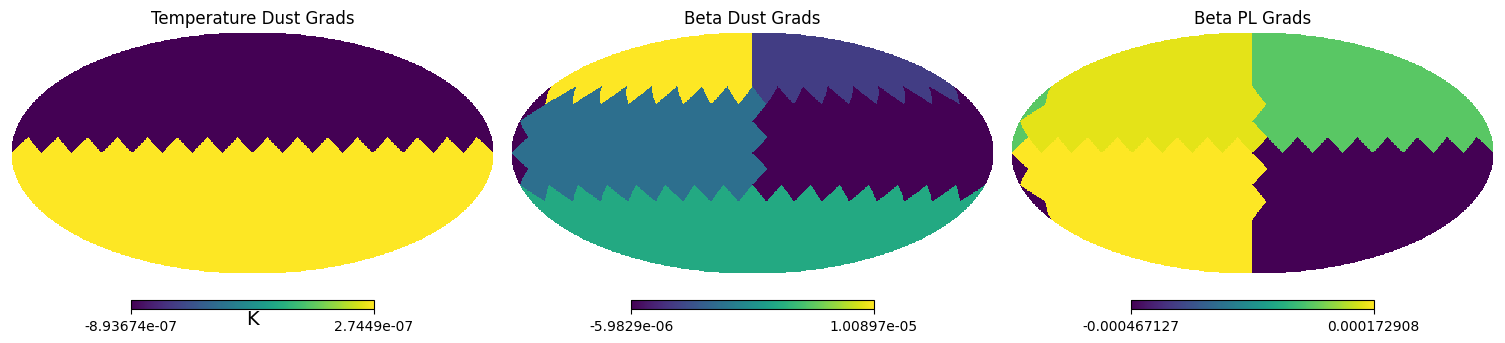

In [68]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = grads['temp_dust'][temp_dust_patch_indices]
beta_dust_map = grads['beta_dust'][beta_dust_patch_indices]
beta_pl_map = grads['beta_pl'][beta_pl_patch_indices]

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()


In [76]:
all_pixel_grads =  jax.grad(likelihood)(all_pixels_param,all_patches,d)

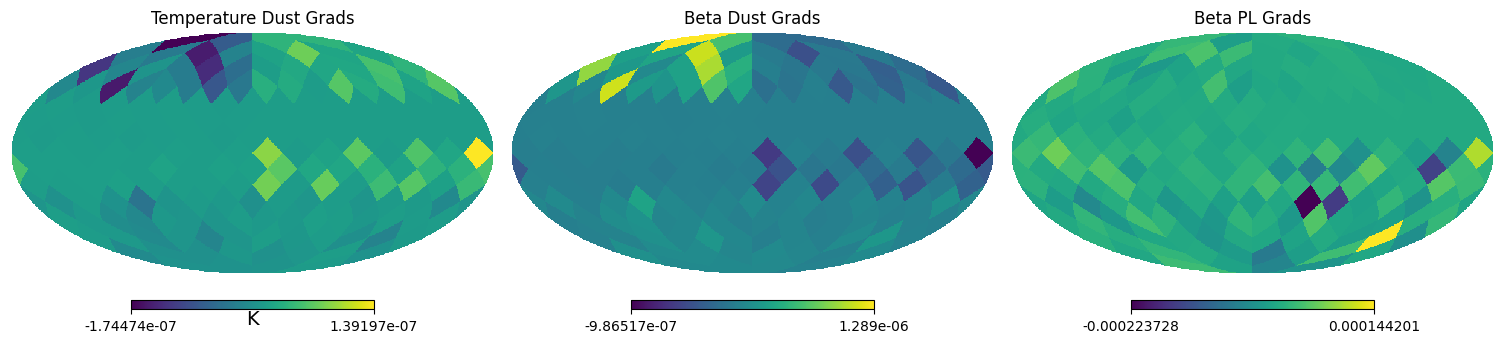

In [77]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = all_pixel_grads['temp_dust']
beta_dust_map = all_pixel_grads['beta_dust']
beta_pl_map = all_pixel_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()


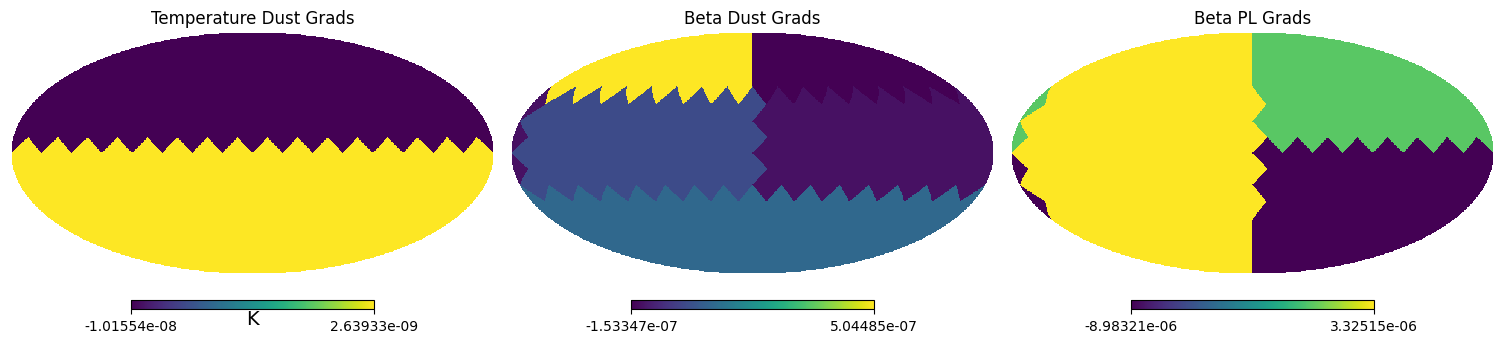

In [ ]:
def average_grads(grads, patch_indices , patch_count):
    for patch_index in range(patch_count):
        grads = grads.at[np.where(patch_indices == patch_index)].set(jnp.mean(grads[np.where(patch_indices == patch_index)]))

    return grads

def uncluster(grads, patch_indices , patch_count):
    vals = jnp.zeros_like(patch_count)
    for patch_index in range(patch_count):
        vals = vals.at[patch_index].set(jnp.mean(grads[np.where(patch_indices == patch_index)]))

    return vals

temp_dust_grads = average_grads(all_pixel_grads['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)
beta_dust_grads = average_grads(all_pixel_grads['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)
beta_pl_grads = average_grads(all_pixel_grads['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_grads, title='Temperature Dust Grads', sub=(1, 3, 1), unit="K")
hp.mollview(beta_dust_grads, title='Beta Dust Grads', sub=(1, 3, 2), unit="")
hp.mollview(beta_pl_grads, title='Beta PL Grads', sub=(1, 3, 3), unit="")

# Display the combined plot
plt.show()

In [82]:
wrong_all_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), all_pixels_param)

In [83]:
import jaxopt
from furax._base.config import ConfigState , Config
import lineax as lx

with Config(solver=lx.CG(rtol=1e-6, atol=1e-6, max_steps=6000)):

    solver = jaxopt.ScipyMinimize(fun=likelihood,
                                method='TNC',
                                maxiter=1000,
                                jit=True,
                                tol=1e-10)
    %timeit  solver.run(best_params,patch_indices, d).params['beta_pl'].block_until_ready()

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


726 ms ± 56.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [84]:
optimized_params = solver.run(best_params,patch_indices, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{optimized_params['beta_dust']}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{optimized_params['beta_pl']}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{optimized_params['temp_dust']}")

Best params beta_dust 
[1.5 2.  2.5 3.  3.5]
Optimized params beta_dust 
[1.49999889 2.00000281 2.49999994 3.00000014 3.49999994]
--------------------------------------------------
Best params beta_pl 
[-2.5        -2.33333333 -2.16666667 -2.        ]
Optimized params beta_pl 
[-2.5        -2.33333333 -2.16666667 -1.99999999]
--------------------------------------------------
Best params temp_dust 
[20. 30.]
Optimized params temp_dust 
[20.00000124 30.00000012]


In [87]:
with Config(solver=lx.CG(rtol=1e-2, atol=1e-2, max_steps=60000)):
    optimized_params = solver.run(wrong_all_params,all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{average_grads(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{average_grads(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{average_grads(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}")

jax.pure_callback failed
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 94, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/equinox/_errors.py", line 89, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the error cannot be displayed. (Probably you are seeing a very large but uninformative error me

XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 1896, in _run_once
  File "/home/wass

In [88]:
optimized_params = solver.run(all_pixels_param,all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{average_grads(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}")
print("-"*50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{average_grads(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}")
print("-"*50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{average_grads(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}")

Best params beta_dust 
[1.5 2.  2.5 3.  3.5]
Optimized params beta_dust 
[1.5 1.5 2.  2.  1.5 1.5 1.5 1.5 2.  2.  2.  2.  1.5 1.5 1.5 1.5 1.5 1.5
 2.  2.  2.  2.  2.  2.  1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 2.  2.  2.  2.
 2.  2.  2.  2.  2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 3.  3.  3.  3.  3.  3.
 3.  3.  2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 3.  3.  3.  3.  3.  3.  3.  3.
 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 3.  3.  3.  3.  3.  3.  3.  3.  2.5 2.5
 2.5 2.5 2.5 2.5 2.5 2.5 3.  3.  3.  3.  3.  3.  3.  3.  2.5 2.5 2.5 2.5
 2.5 2.5 2.5 2.5 3.  3.  3.  3.  3.  3.  3.  3.  2.5 2.5 2.5 2.5 2.5 2.5
 2.5 2.5 3.  3.  3.  3.  3.  3.  3.  3.  3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5
 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5
 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5
 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5]
--------------------------------------------------
Best params beta_pl 
[-2.5        -2.33333333 -2.16666667 -2.        ]
Optimized params beta_pl 
[-

In [ ]:
params = {
    'temp_dust': jnp.array([20.0, 25.0, 30.0]) + jax.random.normal(jax.random.PRNGKey(1), (3,)) * 3,
    'beta_dust': jnp.array([1.5, 2.0, 2.5, 3.0, 3.5]) + jnp.abs(jax.random.normal(jax.random.PRNGKey(2), (5,)) * 0.7),
    'beta_pl': jnp.array([-2.5, -2.0]) + jnp.abs(jax.random.normal(jax.random.PRNGKey(3), (2,)) * 0.7),
}

print(f"changed params")
print(params['temp_dust'])
print(params['beta_dust'])
print(params['beta_pl'])
print(f"best_params ")
print(best_params['temp_dust'])
print(best_params['beta_dust'])
print(best_params['beta_pl'])

optimized_params = solver.run(params,patch_indices, d).params
optimized_params
# Cannot inverse (max iter reached) 

In [ ]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro import plate
from furax.landscapes import HealpixLandscape
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)  # Assuming this is already set
in_structure = HealpixLandscape(nside, stokes_type).structure
# Function to calculate the Gaussian log-likelihood based on `d` and mixing matrix `A`
@jax.jit
def log_likelihood(params,patch_indices, d):
    # Create the mixing matrix operator `A` based on `params` without needing `sky`
    A = make_mixing_matrix_operator(params, patch_indices , in_structure=in_structure)  # Pass shape of `d` to `make_mixing_matrix_operator`
    
    # Project data using `A` and noise inverse `invN`
    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))  # Computes likelihood term
    summed_likelihood = jax.tree.reduce(operator.add, l)   # Summing over components
    
    return summed_likelihood  # Positive log-likelihood value

# Define the NumPyro model
def model(patch_indices,d):
    # Define priors for spectral parameters
    with plate("temp_dust_patches", temp_dust_patch_count):
        temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 50.))
    with plate("beta_dust_patches", beta_dust_patch_count):
        beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 3.0))
    with plate("beta_pl_patches", beta_pl_patch_count):
        beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params,patch_indices , d))

# Run MCMC sampling with a reduced sample count for quick testing
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)  # Adjust sample count for speed
mcmc.run(rng_key, patch_indices=patch_indices , d=d)
samples = mcmc.get_samples()

mcmc.print_summary()

In [ ]:
# Updated NumPyro model with tighter priors
def model(patch_indices, d):
    # Define tighter priors for spectral parameters
    with plate("temp_dust_patches", temp_dust_patch_count):
        temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 25.))
    with plate("beta_dust_patches", beta_dust_patch_count):
        beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 2.0))
    with plate("beta_pl_patches", beta_pl_patch_count):
        beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params, patch_indices, d))

# Run MCMC sampling with tighter priors
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
from numpyro.handlers import condition

conditioned_model = condition(model, {'beta_pl':  jnp.array([-2.5, -2.0])})
mcmc = MCMC(NUTS(conditioned_model), num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
mcmc.print_summary()


Array([1.5, 2. , 2.5, 3. , 3.5], dtype=float64)

In [ ]:
conditioned_model = condition(model, {'temp_dust': jnp.array([20.0, 25.0, 30.0]) , 'beta_pl':  jnp.array([-2.5, -2.0])})
mcmc = MCMC(NUTS(conditioned_model), num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
mcmc.print_summary()
best_params['beta_dust']



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
beta_dust[0]      1.49      0.25      1.48      1.12      1.95    665.56      1.00
beta_dust[1]      1.66      0.24      1.70      1.29      2.00    683.57      1.00
beta_dust[2]      1.77      0.19      1.82      1.49      2.00    365.20      1.01
beta_dust[3]      1.85      0.14      1.90      1.66      2.00    382.88      1.00
beta_dust[4]      1.87      0.13      1.91      1.71      2.00    596.20      1.00

Number of divergences: 0


Array([1.5, 2. , 2.5, 3. , 3.5], dtype=float64)

In [45]:
# Updated NumPyro model with tighter priors
def non_plated_model(patch_indices, d):
    # Define tighter priors for spectral parameters
    temp_dust = numpyro.sample("temp_dust", dist.Uniform(15., 25.) , sample_shape=(temp_dust_patch_count,))
    beta_dust = numpyro.sample("beta_dust", dist.Uniform(1.0, 2.0) , sample_shape=(beta_dust_patch_count,))
    beta_pl = numpyro.sample("beta_pl", dist.Uniform(-6.0, -1.0) , sample_shape=(beta_pl_patch_count,))

    # Pack parameters to use in the likelihood function
    params = {
        'temp_dust': temp_dust,
        'beta_dust': beta_dust,
        'beta_pl': beta_pl
    }

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor("log_likelihood", log_likelihood(params, patch_indices, d))

In [47]:
conditioned_model = condition(non_plated_model, {'temp_dust': jnp.array([20.0, 25.0, 30.0]) , 'beta_pl':  jnp.array([-2.5, -2.0])})
mcmc = MCMC(NUTS(conditioned_model), num_warmup=1000, num_samples=5000)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
mcmc.print_summary()
best_params['beta_dust']


sample: 100%|██████████| 6000/6000 [10:41<00:00,  9.36it/s, 7 steps of size 5.54e-01. acc. prob=0.91] 



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
beta_dust[0]      1.50      0.27      1.51      1.09      1.96   5763.89      1.00
beta_dust[1]      1.65      0.24      1.69      1.29      2.00   6756.65      1.00
beta_dust[2]      1.79      0.17      1.83      1.54      2.00   6228.59      1.00
beta_dust[3]      1.85      0.14      1.89      1.65      2.00   6475.36      1.00
beta_dust[4]      1.87      0.12      1.90      1.71      2.00   5786.67      1.00

Number of divergences: 0


Array([1.5, 2. , 2.5, 3. , 3.5], dtype=float64)